# 05_visualizations

Visualization notebook for the usable-only cycle time summaries.

This notebook:
- loads the three summary CSV files
- checks the schema defensively
- creates a small set of comparison plots
- saves figures into the repository under `reports/visualizations/`

Main focus:
- coverage differences
- median differences
- spread differences
- distribution differences across CT definitions

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Paths and file discovery

In [2]:
def find_project_root(start=None):
    cwd = Path(start or Path.cwd()).resolve()

    candidates = [
        cwd,
        cwd.parent,
        cwd / "SoftwareProcess",
        cwd.parent / "SoftwareProcess",
        cwd.parent.parent,
        cwd.parent.parent / "SoftwareProcess",
    ]

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        if candidate not in seen:
            seen.add(candidate)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if (candidate / "reports" / "summaries").exists():
            return candidate

    return None


def locate_file(filename, start=None):
    cwd = Path(start or Path.cwd()).resolve()
    project_root = find_project_root(cwd)

    search_dirs = []

    if project_root is not None:
        search_dirs.extend([
            project_root / "reports" / "summaries",
            project_root / "notebooks",
            project_root,
        ])

    search_dirs.extend([
        cwd,
        cwd.parent,
        cwd / "reports" / "summaries",
        cwd.parent / "reports" / "summaries",
        cwd.parent.parent / "reports" / "summaries",
    ])

    seen = set()
    unique_dirs = []
    for directory in search_dirs:
        if directory not in seen:
            seen.add(directory)
            unique_dirs.append(directory)

    for directory in unique_dirs:
        path = directory / filename
        if path.exists():
            return path

    checked = "\n".join(f"- {d}" for d in unique_dirs)
    raise FileNotFoundError(
        f"Could not find {filename}. Checked:\n{checked}"
    )


PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    print("Project root not auto-detected from current working directory.")
    print("Falling back to local file discovery.")
else:
    print("Project root:", PROJECT_ROOT)

coverage_path = locate_file("coverage_table_usable_only.csv")
summary_path = locate_file("ct_summary_table_usable_only.csv")
long_path = locate_file("cycle_time_long_issue_level_usable_only.csv")

if PROJECT_ROOT is None:
    OUTPUT_ROOT = Path.cwd()
else:
    OUTPUT_ROOT = PROJECT_ROOT

VIS_DIR = OUTPUT_ROOT / "reports" / "visualizations"
PNG_DIR = VIS_DIR / "png"
SVG_DIR = VIS_DIR / "svg"

VIS_DIR.mkdir(parents=True, exist_ok=True)
PNG_DIR.mkdir(parents=True, exist_ok=True)
SVG_DIR.mkdir(parents=True, exist_ok=True)

print("Coverage file:", coverage_path)
print("Summary file :", summary_path)
print("Long file    :", long_path)
print("Output dir   :", VIS_DIR)

Project root: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess
Coverage file: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/summaries/coverage_table_usable_only.csv
Summary file : /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/summaries/ct_summary_table_usable_only.csv
Long file    : /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/summaries/cycle_time_long_issue_level_usable_only.csv
Output dir   : /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations


## Load data

In [3]:
coverage_df = pd.read_csv(coverage_path)
summary_df = pd.read_csv(summary_path)
long_df = pd.read_csv(long_path, low_memory=False)

print("coverage_df:", coverage_df.shape)
print("summary_df :", summary_df.shape)
print("long_df    :", long_df.shape)

display(coverage_df.head())
display(summary_df.head())
display(long_df.head())

coverage_df: (18, 8)
summary_df : (18, 27)
long_df    : (91920, 18)


,Project,CT_Definition,CT_Column,N_total,N_missing,N_nonpositive,N_usable,Coverage_pct
0,JRACLOUD,CT1,CT1_Resolution_Time_Minutes,1646,0,2,1644,99.88
1,JRACLOUD,CT2,CT2_In_Progress_Minutes,1646,0,1436,210,12.76
2,JRACLOUD,CT3,CT3_Resolution_minus_Created_Minutes,1646,0,2,1644,99.88
3,JRACLOUD,CT4,CT4_Resolution_minus_FirstInProgress_Minutes,1646,1371,32,243,14.76
4,JRACLOUD,CT5,CT5_FinalDone_minus_FirstInProgress_Minutes,1646,1371,15,260,15.80


,Project,CT_Definition,CT_Column,N_total,N_missing,N_nonpositive,N_usable,Coverage_pct,Median_minutes,Q1_minutes,...,Std_minutes,Median_days,Q1_days,Q3_days,IQR_days,P10_days,P90_days,Min_days,Max_days,Mean_days
0,JRACLOUD,CT1,CT1_Resolution_Time_Minutes,1646,0,2,1644,99.88,86002.5,14830.75,...,332251.478093,59.723958,10.299132,354.311285,344.012153,1.205139,573.933333,0.000694,1001.913194,187.827199
1,JRACLOUD,CT2,CT2_In_Progress_Minutes,1646,0,1436,210,12.76,10163.0,1467.25,...,91792.286116,7.057639,1.018924,26.965972,25.947049,0.032569,93.460139,0.000694,485.180556,31.518929
2,JRACLOUD,CT3,CT3_Resolution_minus_Created_Minutes,1646,0,2,1644,99.88,86002.5,14830.75,...,332251.481234,59.723958,10.299132,354.311806,344.012674,1.205139,573.933333,0.000694,1001.913889,187.827206
3,JRACLOUD,CT4,CT4_Resolution_minus_FirstInProgress_Minutes,1646,1371,32,243,14.76,12905.0,2655.00,...,112926.588079,8.961806,1.843750,35.718750,33.875000,0.070694,126.141389,0.000694,499.084028,39.929987
4,JRACLOUD,CT5,CT5_FinalDone_minus_FirstInProgress_Minutes,1646,1371,15,260,15.80,112458.5,9814.25,...,253372.293874,78.096181,6.815451,258.590104,251.774653,0.675556,436.377361,0.000694,581.774306,152.291875


,Project_Key,Issue_ID,Issue_Key,Issue_Type,Priority,Sprint_ID,Sprint_Name,Story_Point,Created,Resolution,First_In_Progress_Timestamp,First_Done_Timestamp,Final_Done_Timestamp,Was_Reopened,CT_Definition,CT_Column,Cycle_Time_Minutes,Usable
0,SERVER,479182,SERVER-32497,Bug,Major - P3,NaN,NaN,NaN,2018-01-01 01:16:56,2018-01-02 17:37:10,NaN,2018-01-02 17:37:10,2018-01-29 17:29:44,0,CT1,CT1_Resolution_Time_Minutes,2420.0,True
1,SERVER,479181,SERVER-32498,Bug,Major - P3,NaN,NaN,NaN,2018-01-01 02:20:46,2018-02-05 16:25:16,2018-01-17 19:47:07,2018-02-05 16:25:16,2018-02-05 16:25:16,0,CT1,CT1_Resolution_Time_Minutes,51244.0,True
2,SERVER,479180,SERVER-32499,Bug,Major - P3,NaN,NaN,NaN,2018-01-01 08:57:08,2018-01-03 04:25:52,NaN,2018-01-03 04:25:52,2018-01-03 04:25:52,0,CT1,CT1_Resolution_Time_Minutes,2608.0,True
3,SERVER,479179,SERVER-32500,Task,Major - P3,NaN,NaN,NaN,2018-01-01 17:23:11,2018-01-01 18:32:41,NaN,2018-01-01 18:32:41,2018-01-29 17:30:19,0,CT1,CT1_Resolution_Time_Minutes,69.0,True
4,SERVER,479178,SERVER-32501,Improvement,Major - P3,NaN,NaN,NaN,2018-01-02 05:27:53,2018-01-15 05:23:57,2018-01-05 00:12:28,2018-01-15 05:23:57,2018-01-15 05:23:57,0,CT1,CT1_Resolution_Time_Minutes,18716.0,True


## Normalize schema

In [4]:
coverage_df.columns = [c.strip() for c in coverage_df.columns]
summary_df.columns = [c.strip() for c in summary_df.columns]
long_df.columns = [c.strip() for c in long_df.columns]

if "Project" not in coverage_df.columns and "Project_Key" in coverage_df.columns:
    coverage_df = coverage_df.rename(columns={"Project_Key": "Project"})

if "Project" not in summary_df.columns and "Project_Key" in summary_df.columns:
    summary_df = summary_df.rename(columns={"Project_Key": "Project"})

if "Project" not in long_df.columns and "Project_Key" in long_df.columns:
    long_df = long_df.rename(columns={"Project_Key": "Project"})

if "Cycle_Time_Days" not in long_df.columns:
    if "Cycle_Time_Minutes" in long_df.columns:
        long_df["Cycle_Time_Days"] = pd.to_numeric(
            long_df["Cycle_Time_Minutes"], errors="coerce"
        ) / 1440.0

required_coverage = {"Project", "CT_Definition", "Coverage_pct"}
required_summary = {"Project", "CT_Definition", "Median_days", "IQR_days"}
required_long = {"Project", "CT_Definition", "Cycle_Time_Days"}

assert required_coverage.issubset(coverage_df.columns), (
    f"Missing coverage columns: {required_coverage - set(coverage_df.columns)}"
)
assert required_summary.issubset(summary_df.columns), (
    f"Missing summary columns: {required_summary - set(summary_df.columns)}"
)
assert required_long.issubset(long_df.columns), (
    f"Missing long columns: {required_long - set(long_df.columns)}"
)

coverage_df["Coverage_pct"] = pd.to_numeric(coverage_df["Coverage_pct"], errors="coerce")
summary_df["Median_days"] = pd.to_numeric(summary_df["Median_days"], errors="coerce")
summary_df["IQR_days"] = pd.to_numeric(summary_df["IQR_days"], errors="coerce")
long_df["Cycle_Time_Days"] = pd.to_numeric(long_df["Cycle_Time_Days"], errors="coerce")

if "Usable" in long_df.columns:
    long_df = long_df[long_df["Usable"].fillna(False).astype(bool)].copy()

long_df = long_df[long_df["Cycle_Time_Days"].notna() & (long_df["Cycle_Time_Days"] > 0)].copy()

print("Normalized shapes:")
print("coverage_df:", coverage_df.shape)
print("summary_df :", summary_df.shape)
print("long_df    :", long_df.shape)

Normalized shapes:
coverage_df: (18, 8)
summary_df : (18, 27)
long_df    : (91920, 19)


## Ordering and save helper

In [5]:
all_projects = set(coverage_df["Project"]).union(summary_df["Project"]).union(long_df["Project"])
preferred_project_order = ["SERVER", "MDL", "JRACLOUD"]
project_order = [p for p in preferred_project_order if p in all_projects] + [
    p for p in sorted(all_projects) if p not in preferred_project_order
]

def ct_sort_key(ct):
    digits = "".join(ch for ch in str(ct) if ch.isdigit())
    return int(digits) if digits else 999

ct_order = sorted(
    set(coverage_df["CT_Definition"]).union(summary_df["CT_Definition"]).union(long_df["CT_Definition"]),
    key=ct_sort_key,
)

def save_figure(fig, name, dpi=200):
    png_path = PNG_DIR / f"{name}.png"
    svg_path = SVG_DIR / f"{name}.svg"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", svg_path)

print("Project order:", project_order)
print("CT order     :", ct_order)

Project order: ['SERVER', 'MDL', 'JRACLOUD']
CT order     : ['CT1', 'CT2', 'CT3', 'CT4', 'CT5', 'CT6']


## Quick check: CT1 vs CT3

In [6]:
ct13_summary = summary_df[summary_df["CT_Definition"].isin(["CT1", "CT3"])].copy()
ct13_coverage = coverage_df[coverage_df["CT_Definition"].isin(["CT1", "CT3"])].copy()

if not ct13_summary.empty:
    print("Median days:")
    display(
        ct13_summary.pivot(index="Project", columns="CT_Definition", values="Median_days")
        .reindex(index=project_order)
    )

    print("IQR days:")
    display(
        ct13_summary.pivot(index="Project", columns="CT_Definition", values="IQR_days")
        .reindex(index=project_order)
    )

    print("Coverage %:")
    display(
        ct13_coverage.pivot(index="Project", columns="CT_Definition", values="Coverage_pct")
        .reindex(index=project_order)
    )
else:
    print("CT1/CT3 comparison not available.")

Median days:


CT_Definition,CT1,CT3
Project,,
SERVER,14.267361,14.267361
MDL,19.357292,19.375694
JRACLOUD,59.723958,59.723958


IQR days:


CT_Definition,CT1,CT3
Project,,
SERVER,43.673958,43.673958
MDL,59.241319,59.241319
JRACLOUD,344.012153,344.012674


Coverage %:


CT_Definition,CT1,CT3
Project,,
SERVER,99.93,99.93
MDL,99.90,99.90
JRACLOUD,99.88,99.88


## Coverage heatmap

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/coverage_heatmap.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/coverage_heatmap.svg


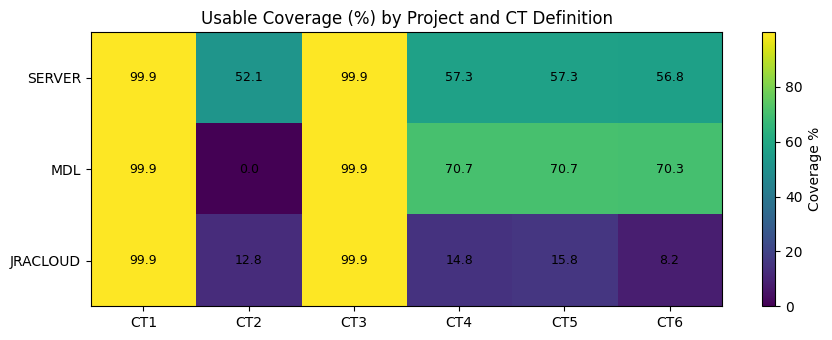

In [7]:
coverage_pivot = (
    coverage_df
    .pivot(index="Project", columns="CT_Definition", values="Coverage_pct")
    .reindex(index=project_order, columns=ct_order)
)

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(coverage_pivot.values, aspect="auto")

ax.set_title("Usable Coverage (%) by Project and CT Definition")
ax.set_xticks(range(len(coverage_pivot.columns)))
ax.set_xticklabels(coverage_pivot.columns)
ax.set_yticks(range(len(coverage_pivot.index)))
ax.set_yticklabels(coverage_pivot.index)

for i in range(coverage_pivot.shape[0]):
    for j in range(coverage_pivot.shape[1]):
        value = coverage_pivot.iloc[i, j]
        label = "" if pd.isna(value) else f"{value:.1f}"
        ax.text(j, i, label, ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Coverage %")
fig.tight_layout()

save_figure(fig, "coverage_heatmap")
plt.show()

## Grouped coverage bars

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/coverage_grouped_bars.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/coverage_grouped_bars.svg


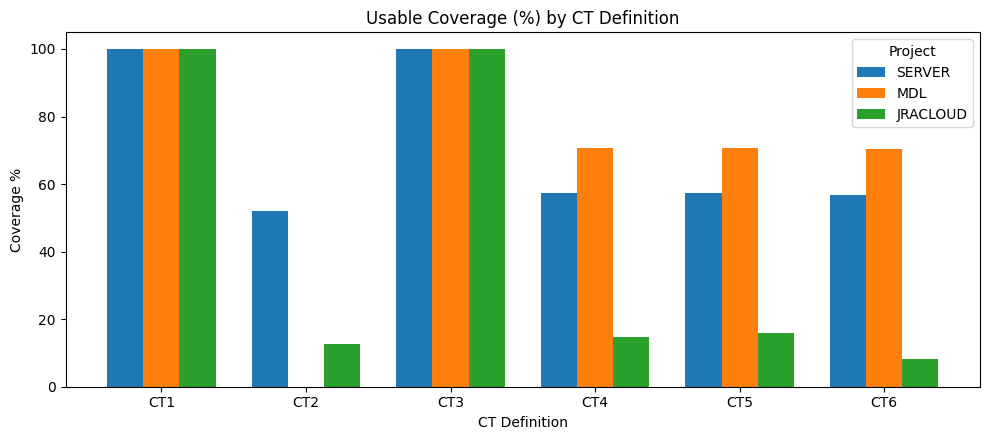

In [8]:
plot_df = coverage_df.dropna(subset=["Coverage_pct"]).copy()

fig, ax = plt.subplots(figsize=(10, 4.5))

bar_width = 0.25
x = np.arange(len(ct_order))

for idx, project in enumerate(project_order):
    proj_df = (
        plot_df[plot_df["Project"] == project]
        .set_index("CT_Definition")
        .reindex(ct_order)
    )
    y = proj_df["Coverage_pct"].values
    ax.bar(x + idx * bar_width, y, width=bar_width, label=project)

ax.set_title("Usable Coverage (%) by CT Definition")
ax.set_xlabel("CT Definition")
ax.set_ylabel("Coverage %")
ax.set_xticks(x + bar_width * (len(project_order) - 1) / 2)
ax.set_xticklabels(ct_order)
ax.legend(title="Project")

fig.tight_layout()

save_figure(fig, "coverage_grouped_bars")
plt.show()

## Median heatmap

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/median_heatmap.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/median_heatmap.svg


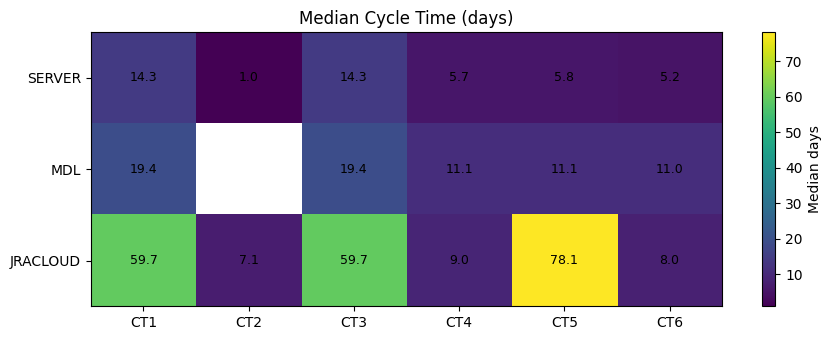

In [9]:
median_pivot = (
    summary_df
    .pivot(index="Project", columns="CT_Definition", values="Median_days")
    .reindex(index=project_order, columns=ct_order)
)

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(median_pivot.values, aspect="auto")

ax.set_title("Median Cycle Time (days)")
ax.set_xticks(range(len(median_pivot.columns)))
ax.set_xticklabels(median_pivot.columns)
ax.set_yticks(range(len(median_pivot.index)))
ax.set_yticklabels(median_pivot.index)

for i in range(median_pivot.shape[0]):
    for j in range(median_pivot.shape[1]):
        value = median_pivot.iloc[i, j]
        label = "" if pd.isna(value) else f"{value:.1f}"
        ax.text(j, i, label, ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Median days")
fig.tight_layout()

save_figure(fig, "median_heatmap")
plt.show()

## IQR heatmap

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/iqr_heatmap.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/iqr_heatmap.svg


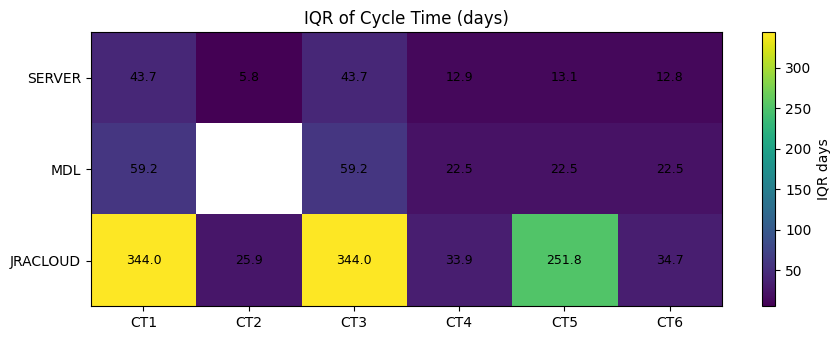

In [10]:
iqr_pivot = (
    summary_df
    .pivot(index="Project", columns="CT_Definition", values="IQR_days")
    .reindex(index=project_order, columns=ct_order)
)

fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(iqr_pivot.values, aspect="auto")

ax.set_title("IQR of Cycle Time (days)")
ax.set_xticks(range(len(iqr_pivot.columns)))
ax.set_xticklabels(iqr_pivot.columns)
ax.set_yticks(range(len(iqr_pivot.index)))
ax.set_yticklabels(iqr_pivot.index)

for i in range(iqr_pivot.shape[0]):
    for j in range(iqr_pivot.shape[1]):
        value = iqr_pivot.iloc[i, j]
        label = "" if pd.isna(value) else f"{value:.1f}"
        ax.text(j, i, label, ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="IQR days")
fig.tight_layout()

save_figure(fig, "iqr_heatmap")
plt.show()

## Distribution differences: boxplots

In [11]:
dist_df = long_df.dropna(subset=["Cycle_Time_Days"]).copy()
dist_df = dist_df[dist_df["Cycle_Time_Days"] > 0].copy()

print("Usable rows:", dist_df.shape[0])

counts = (
    dist_df.groupby(["Project", "CT_Definition"])["Cycle_Time_Days"]
    .size()
    .unstack(fill_value=0)
    .reindex(index=project_order, columns=ct_order)
)

display(counts)

Usable rows: 91920


CT_Definition,CT1,CT2,CT3,CT4,CT5,CT6
Project,,,,,,
SERVER,15963,8323,15963,9146,9146,9078
MDL,4896,0,4896,3463,3463,3447
JRACLOUD,1644,210,1644,243,260,135


/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_81330/2257150827.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_81330/2257150827.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_81330/2257150827.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/boxplots_actual_days_capped.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/boxplots_actual_days_capped.svg


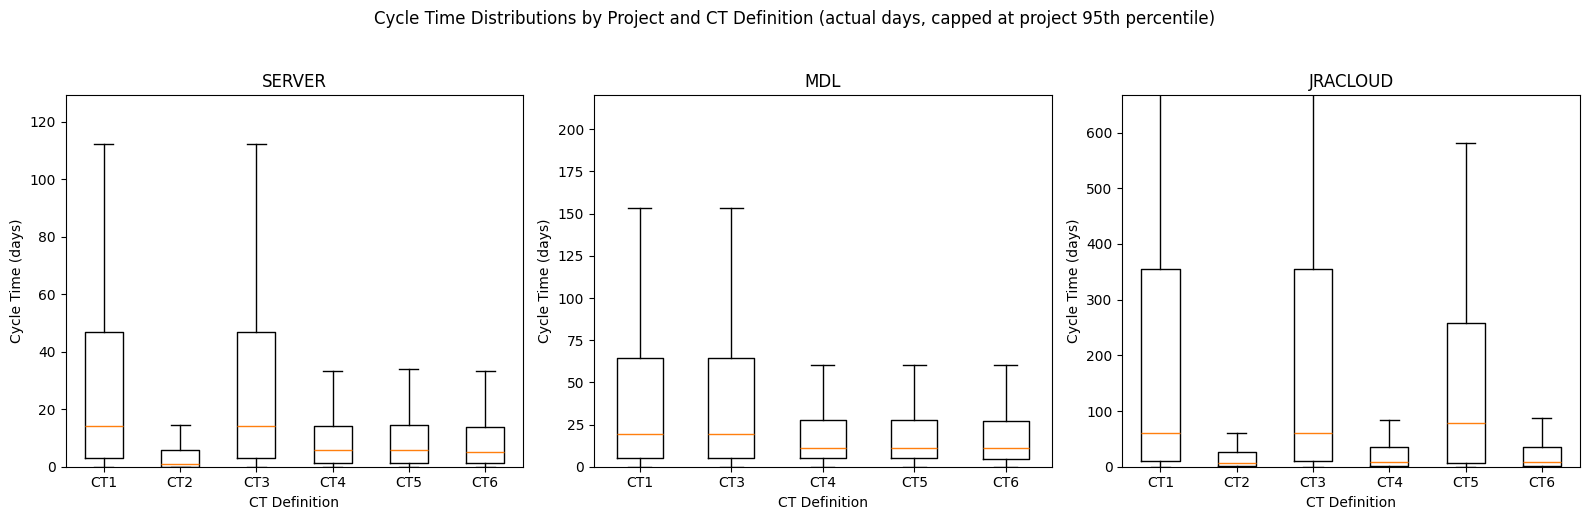

In [12]:
# Use actual day values on the axis.
# Cap the visible range at the 95th percentile within each project
# so the boxes stay readable without switching to log scale.

fig, axes = plt.subplots(1, len(project_order), figsize=(16, 5), sharey=False)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = dist_df[dist_df["Project"] == project].copy()

    available_cts = [
        ct for ct in ct_order
        if ct in proj_df["CT_Definition"].astype(str).unique()
    ]

    data = []
    labels = []

    for ct in available_cts:
        values = proj_df.loc[
            proj_df["CT_Definition"].astype(str) == ct,
            "Cycle_Time_Days"
        ].dropna().values

        if len(values) > 0:
            data.append(values)
            labels.append(ct)

    if len(data) == 0:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(project)
    ax.set_xlabel("CT Definition")
    ax.set_ylabel("Cycle Time (days)")

    # Cap view at project-specific 95th percentile
    upper = np.percentile(proj_df["Cycle_Time_Days"], 95)
    ax.set_ylim(0, upper * 1.05)

fig.suptitle("Cycle Time Distributions by Project and CT Definition (actual days, capped at project 95th percentile)", y=1.03)
fig.tight_layout()

save_figure(fig, "boxplots_actual_days_capped")
plt.show()

/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_81330/2835675062.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_81330/2835675062.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/var/folders/hy/9mxkxprj2dlb6w9_fhfd2zzh0000gn/T/ipykernel_81330/2835675062.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/boxplots_actual_days_global_cap.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/boxplots_actual_days_global_cap.svg


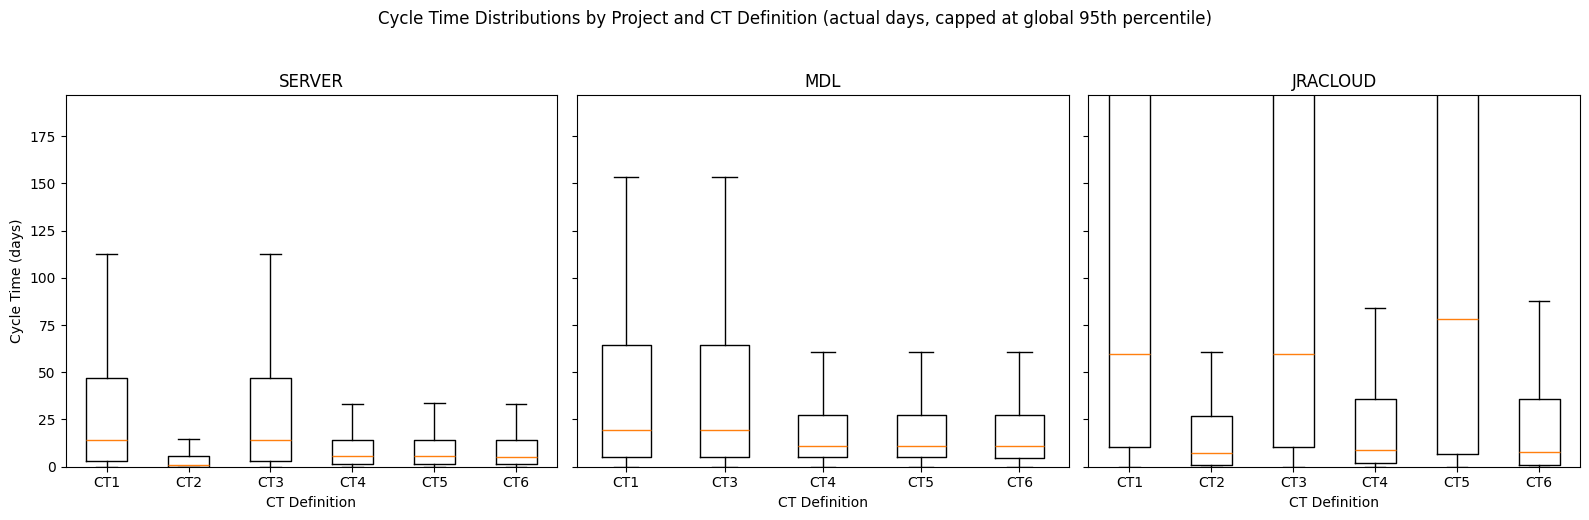

In [13]:
# Same y-axis across all projects using a global cap.
# Easier to compare across projects, but some within-project detail may be compressed.

global_upper = np.percentile(dist_df["Cycle_Time_Days"], 95)

fig, axes = plt.subplots(1, len(project_order), figsize=(16, 5), sharey=True)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = dist_df[dist_df["Project"] == project].copy()

    available_cts = [
        ct for ct in ct_order
        if ct in proj_df["CT_Definition"].astype(str).unique()
    ]

    data = []
    labels = []

    for ct in available_cts:
        values = proj_df.loc[
            proj_df["CT_Definition"].astype(str) == ct,
            "Cycle_Time_Days"
        ].dropna().values

        if len(values) > 0:
            data.append(values)
            labels.append(ct)

    if len(data) == 0:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(project)
    ax.set_xlabel("CT Definition")
    ax.set_ylim(0, global_upper * 1.05)

axes[0].set_ylabel("Cycle Time (days)")
fig.suptitle("Cycle Time Distributions by Project and CT Definition (actual days, capped at global 95th percentile)", y=1.03)
fig.tight_layout()

save_figure(fig, "boxplots_actual_days_global_cap")
plt.show()

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/median_iqr_pointrange.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/median_iqr_pointrange.svg


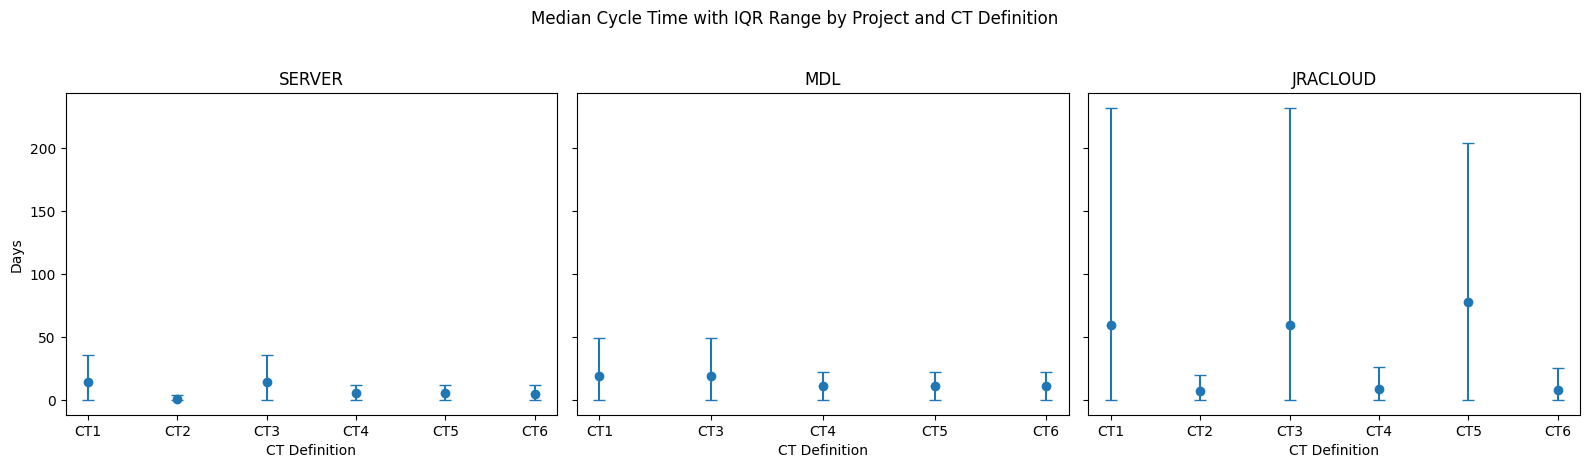

In [14]:
# Summary plot using median and IQR only.
# Very readable and avoids long-tail distortion entirely.

plot_df = summary_df.dropna(subset=["Median_days", "IQR_days"]).copy()

fig, axes = plt.subplots(1, len(project_order), figsize=(16, 4.5), sharey=True)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = (
        plot_df[plot_df["Project"] == project]
        .sort_values("CT_Definition")
        .copy()
    )

    x_labels = proj_df["CT_Definition"].astype(str).tolist()
    x = np.arange(len(x_labels))
    med = proj_df["Median_days"].values
    iqr = proj_df["IQR_days"].values

    # Approximate IQR as median ± IQR/2 for a compact visual summary
    lower = np.maximum(0, med - iqr / 2)
    upper = med + iqr / 2
    yerr = np.vstack([med - lower, upper - med])

    ax.errorbar(x, med, yerr=yerr, fmt="o", capsize=4)
    ax.set_title(project)
    ax.set_xlabel("CT Definition")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)

axes[0].set_ylabel("Days")
fig.suptitle("Median Cycle Time with IQR Range by Project and CT Definition", y=1.03)
fig.tight_layout()

save_figure(fig, "median_iqr_pointrange")
plt.show()

## Optional cleaner distribution view without CT3

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/boxplots_selected_cts_actual_days_capped.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/boxplots_selected_cts_actual_days_capped.svg


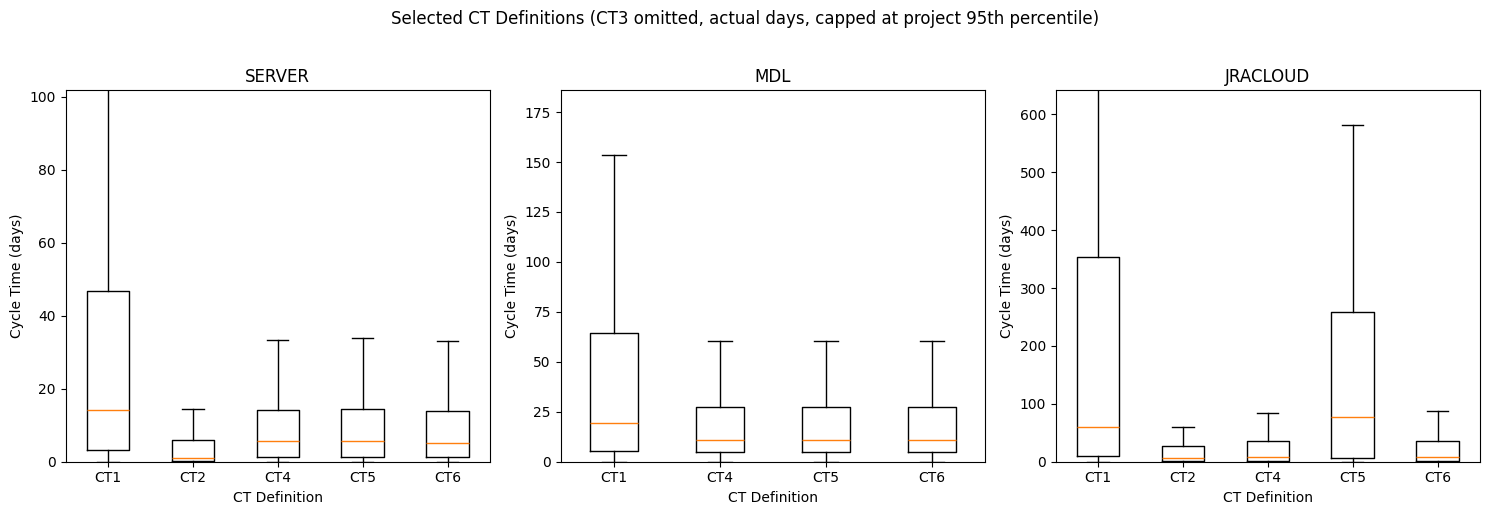

In [15]:
selected_cts = [ct for ct in ["CT1", "CT2", "CT4", "CT5", "CT6"] if ct in ct_order]
selected_df = dist_df[dist_df["CT_Definition"].astype(str).isin(selected_cts)].copy()

fig, axes = plt.subplots(1, len(project_order), figsize=(15, 5), sharey=False)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = selected_df[selected_df["Project"] == project].copy()

    available_cts = [
        ct for ct in selected_cts
        if ct in set(proj_df["CT_Definition"].astype(str))
    ]

    data = [
        proj_df.loc[
            proj_df["CT_Definition"].astype(str) == ct,
            "Cycle_Time_Days"
        ].dropna().values
        for ct in available_cts
    ]

    filtered = [(ct, arr) for ct, arr in zip(available_cts, data) if len(arr) > 0]

    if not filtered:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    labels = [ct for ct, _ in filtered]
    series = [arr for _, arr in filtered]

    ax.boxplot(series, tick_labels=labels, showfliers=False)
    ax.set_title(project)
    ax.set_xlabel("CT Definition")
    ax.set_ylabel("Cycle Time (days)")

    upper = np.percentile(
        proj_df.loc[proj_df["Cycle_Time_Days"] > 0, "Cycle_Time_Days"],
        95
    )
    ax.set_ylim(0, upper * 1.05)

fig.suptitle(
    "Selected CT Definitions (CT3 omitted, actual days, capped at project 95th percentile)",
    y=1.02
)
fig.tight_layout()

save_figure(fig, "boxplots_selected_cts_actual_days_capped")
plt.show()

## same-scale-across-projects version

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/boxplots_selected_cts_actual_days_global_cap.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/boxplots_selected_cts_actual_days_global_cap.svg


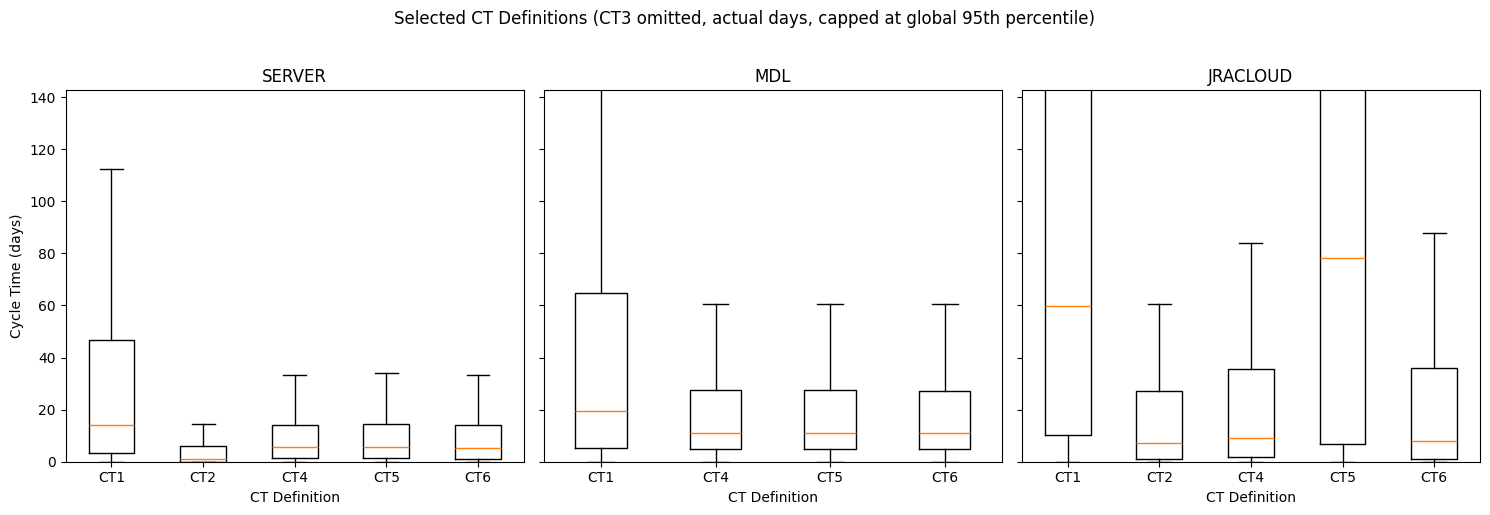

In [16]:
selected_cts = [ct for ct in ["CT1", "CT2", "CT4", "CT5", "CT6"] if ct in ct_order]
selected_df = dist_df[dist_df["CT_Definition"].astype(str).isin(selected_cts)].copy()

global_upper = np.percentile(
    selected_df.loc[selected_df["Cycle_Time_Days"] > 0, "Cycle_Time_Days"],
    95
)

fig, axes = plt.subplots(1, len(project_order), figsize=(15, 5), sharey=True)

if len(project_order) == 1:
    axes = [axes]

for ax, project in zip(axes, project_order):
    proj_df = selected_df[selected_df["Project"] == project].copy()

    available_cts = [
        ct for ct in selected_cts
        if ct in set(proj_df["CT_Definition"].astype(str))
    ]

    data = [
        proj_df.loc[
            proj_df["CT_Definition"].astype(str) == ct,
            "Cycle_Time_Days"
        ].dropna().values
        for ct in available_cts
    ]

    filtered = [(ct, arr) for ct, arr in zip(available_cts, data) if len(arr) > 0]

    if not filtered:
        ax.set_title(project)
        ax.text(0.5, 0.5, "No usable data", ha="center", va="center", transform=ax.transAxes)
        continue

    labels = [ct for ct, _ in filtered]
    series = [arr for _, arr in filtered]

    ax.boxplot(series, tick_labels=labels, showfliers=False)
    ax.set_title(project)
    ax.set_xlabel("CT Definition")
    ax.set_ylim(0, global_upper * 1.05)

axes[0].set_ylabel("Cycle Time (days)")
fig.suptitle(
    "Selected CT Definitions (CT3 omitted, actual days, capped at global 95th percentile)",
    y=1.02
)
fig.tight_layout()

save_figure(fig, "boxplots_selected_cts_actual_days_global_cap")
plt.show()

## Coverage vs median tradeoff

Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/png/coverage_vs_median_scatter.png
Saved: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations/svg/coverage_vs_median_scatter.svg


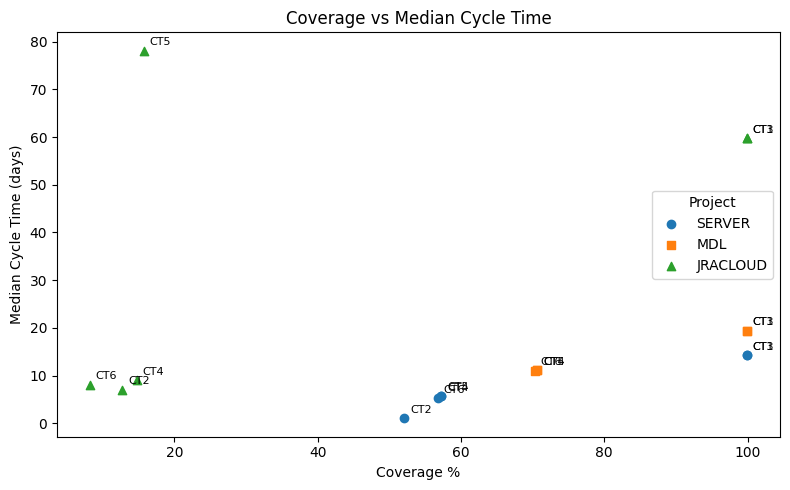

In [17]:
scatter_df = (
    coverage_df[["Project", "CT_Definition", "Coverage_pct"]]
    .merge(
        summary_df[["Project", "CT_Definition", "Median_days"]],
        on=["Project", "CT_Definition"],
        how="inner",
    )
    .dropna(subset=["Coverage_pct", "Median_days"])
    .copy()
)

fig, ax = plt.subplots(figsize=(8, 5))

markers = {"SERVER": "o", "MDL": "s", "JRACLOUD": "^"}

for project in project_order:
    proj_df = scatter_df[scatter_df["Project"] == project]
    ax.scatter(
        proj_df["Coverage_pct"],
        proj_df["Median_days"],
        marker=markers.get(project, "o"),
        label=project,
    )
    for _, row in proj_df.iterrows():
        ax.annotate(
            row["CT_Definition"],
            (row["Coverage_pct"], row["Median_days"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

ax.set_title("Coverage vs Median Cycle Time")
ax.set_xlabel("Coverage %")
ax.set_ylabel("Median Cycle Time (days)")
ax.legend(title="Project")

fig.tight_layout()

save_figure(fig, "coverage_vs_median_scatter")
plt.show()

## Export plot source tables

In [18]:
coverage_pivot.to_csv(VIS_DIR / "coverage_heatmap_source.csv")
median_pivot.to_csv(VIS_DIR / "median_heatmap_source.csv")
iqr_pivot.to_csv(VIS_DIR / "iqr_heatmap_source.csv")
scatter_df.to_csv(VIS_DIR / "coverage_vs_median_source.csv", index=False)
counts.to_csv(VIS_DIR / "boxplot_counts_source.csv")

print("Saved plot source tables to:", VIS_DIR)

Saved plot source tables to: /Users/bjorgvinatli/UvAProjects/Software_Process_Data_Analysis/Experiment1/SoftwareProcess/reports/visualizations


## Output check

In [19]:
print("PNG files:")
for path in sorted(PNG_DIR.glob("*.png")):
    print("-", path.name)

print("\nSVG files:")
for path in sorted(SVG_DIR.glob("*.svg")):
    print("-", path.name)

PNG files:
- boxplots_actual_days_capped.png
- boxplots_actual_days_global_cap.png
- boxplots_logscale_by_project.png
- boxplots_logscale_selected_cts.png
- boxplots_selected_cts_actual_days_capped.png
- boxplots_selected_cts_actual_days_global_cap.png
- coverage_grouped_bars.png
- coverage_heatmap.png
- coverage_vs_median_scatter.png
- iqr_heatmap.png
- median_heatmap.png
- median_iqr_pointrange.png

SVG files:
- boxplots_actual_days_capped.svg
- boxplots_actual_days_global_cap.svg
- boxplots_logscale_by_project.svg
- boxplots_logscale_selected_cts.svg
- boxplots_selected_cts_actual_days_capped.svg
- boxplots_selected_cts_actual_days_global_cap.svg
- coverage_grouped_bars.svg
- coverage_heatmap.svg
- coverage_vs_median_scatter.svg
- iqr_heatmap.svg
- median_heatmap.svg
- median_iqr_pointrange.svg
